In [1]:
import pandas as pd
import numpy as np
from model import *
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from preprocessing import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_auc_score
from data_analyze import *
from imblearn.over_sampling import SMOTE
from sklearn.metrics import *
from explain import *


In [2]:

df = pd.read_csv("heart_failure.csv")

inspect_columns(df)


,column,dtype,nunique,missing,sample_values
0,Age,int64,50,0,"[40, 49, 37, 48, 54, 39, 45, 58, 42, 38]"
1,Sex,object,2,0,"[M, F]"
2,ChestPainType,object,4,0,"[ATA, NAP, ASY, TA]"
3,RestingBP,int64,67,0,"[140, 160, 130, 138, 150, 120, 110, 136, 115, ..."
4,Cholesterol,int64,222,0,"[289, 180, 283, 214, 195, 339, 237, 208, 207, ..."
5,FastingBS,int64,2,0,"[0, 1]"
6,RestingECG,object,3,0,"[Normal, ST, LVH]"
7,MaxHR,int64,119,0,"[172, 156, 98, 108, 122, 170, 142, 130, 120, 99]"
8,ExerciseAngina,object,2,0,"[N, Y]"
9,Oldpeak,float64,53,0,"[0.0, 1.0, 1.5, 2.0, 3.0, 4.0, 0.5, 2.5, 5.0, ..."


#### 숫자로 안 되어있는 건 다 object형임을 확인. object형을 categorical_cols로 간주하고, 남은 numerical_values를 가진 것들을 numeric_cols로 분류한 다음에, categorical_cols은 라벨링으로 전처리하고, numerical_values는 standard scaler로 전처리하자

In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["HeartDisease"]
)

# 타겟 컬럼 이름
TARGET_COL = "HeartDisease"

# object 타입 → 카테고리로 간주
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# 나머지 숫자형 feature들 (타겟은 제외)
numeric_cols = [
    c for c in df.columns
    if c not in categorical_cols + [TARGET_COL]
]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)


Categorical: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numeric: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [4]:

inspector = FeatureInspector(
    df,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    target_col="HeartDisease",
)

# inspector.plot_corr_heatmap(method="pearson")
# spearman으로 보고 싶으면
# inspector.plot_corr_heatmap(method="spearman")

# 전체 열 기준 중복 존재 여부
inspector.has_duplicates()

# Age + Sex 기준으로 중복 존재 여부
inspector.has_duplicates(subset=["Age", "RestingECG", "Sex", "ChestPainType", "FastingBS", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease", "ExerciseAngina", "ST_Slope"])

# 실제 어떤 중복 행인지 확인
dup_rows = inspector.analyze_duplicates()


=== Duplicate Existence Check (all columns) ===
Duplicated rows exist? False
=== Duplicate Existence Check (columns=['Age', 'RestingECG', 'Sex', 'ChestPainType', 'FastingBS', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease', 'ExerciseAngina', 'ST_Slope']) ===
Duplicated rows exist? False
=== Duplicate Row Analysis ===
Criteria: all columns
Number of duplicated rows: 0
No duplicated rows found.


=== Categorical Features ===

[Sex]
Sex
M    725
F    193
Name: count, dtype: int64

[ChestPainType]
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

[RestingECG]
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

[ExerciseAngina]
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

[ST_Slope]
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

=== Numeric Features ===

[Age]
  mean: 53.511
  std:  9.433

[RestingBP]
  mean: 132.397
  std:  18.514

[Cholesterol]
  mean: 198.800
  std:  109.384

[FastingBS]
  mean: 0.233
  std:  0.423

[MaxHR]
  mean: 136.809
  std:  25.460

[Oldpeak]
  mean: 0.887
  std:  1.067


c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Coursework\heart_disease\data_analyze.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index.astype(str), rotation=45, ha="right")
c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Coursework\heart_disease\data_analyze.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index.astype(str), rotation=45, ha="right")
c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Coursework\heart_disease\data_analyze.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index.astype(str), rotation=45, ha="right")
c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Course

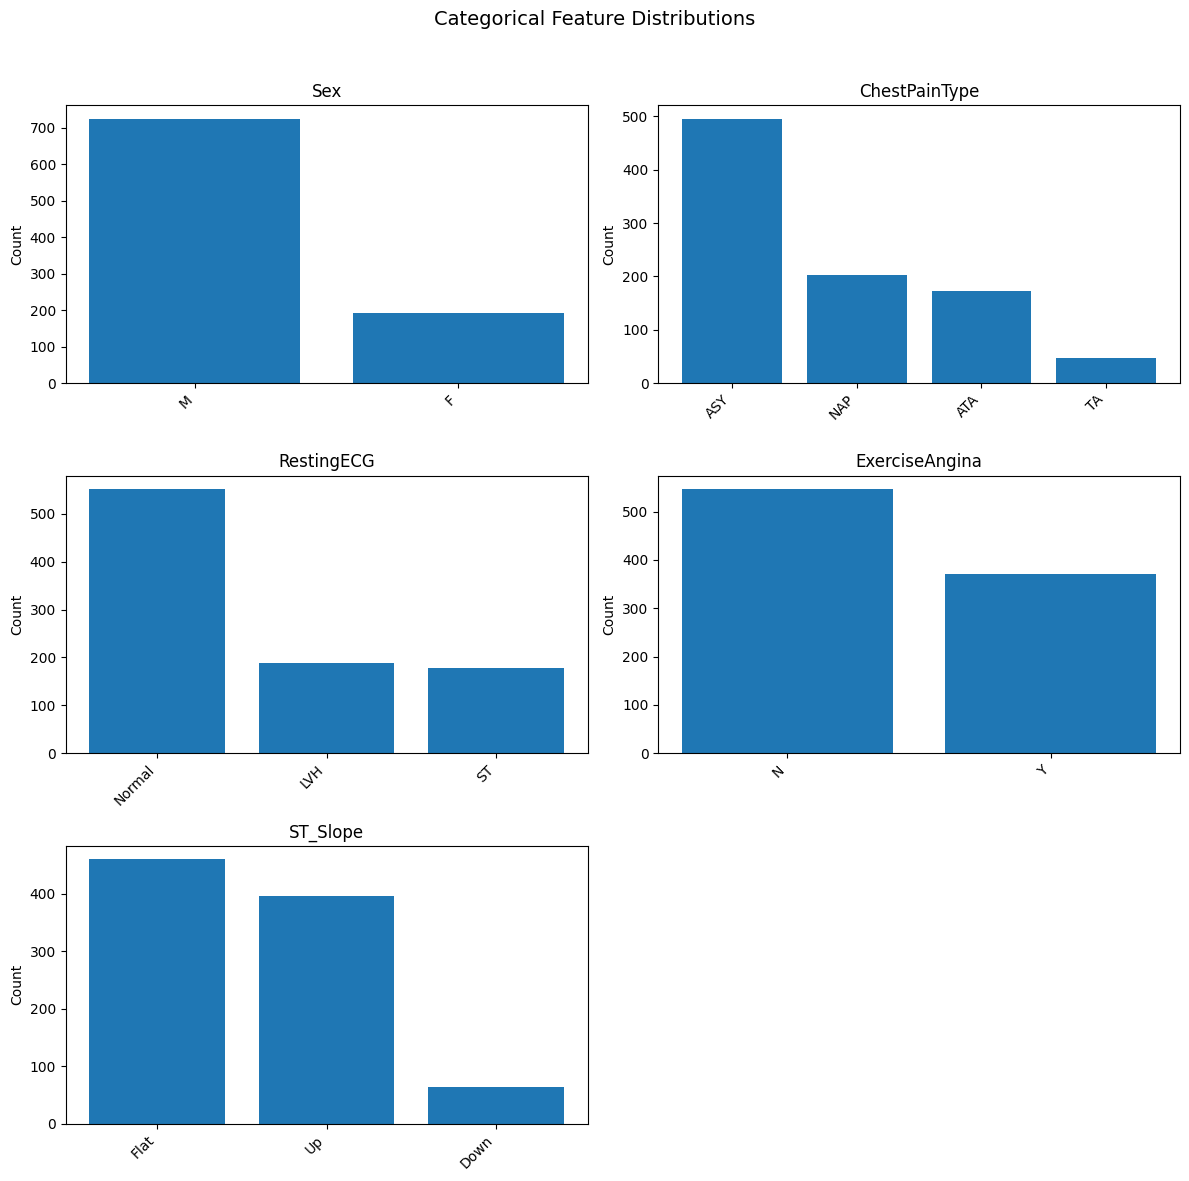

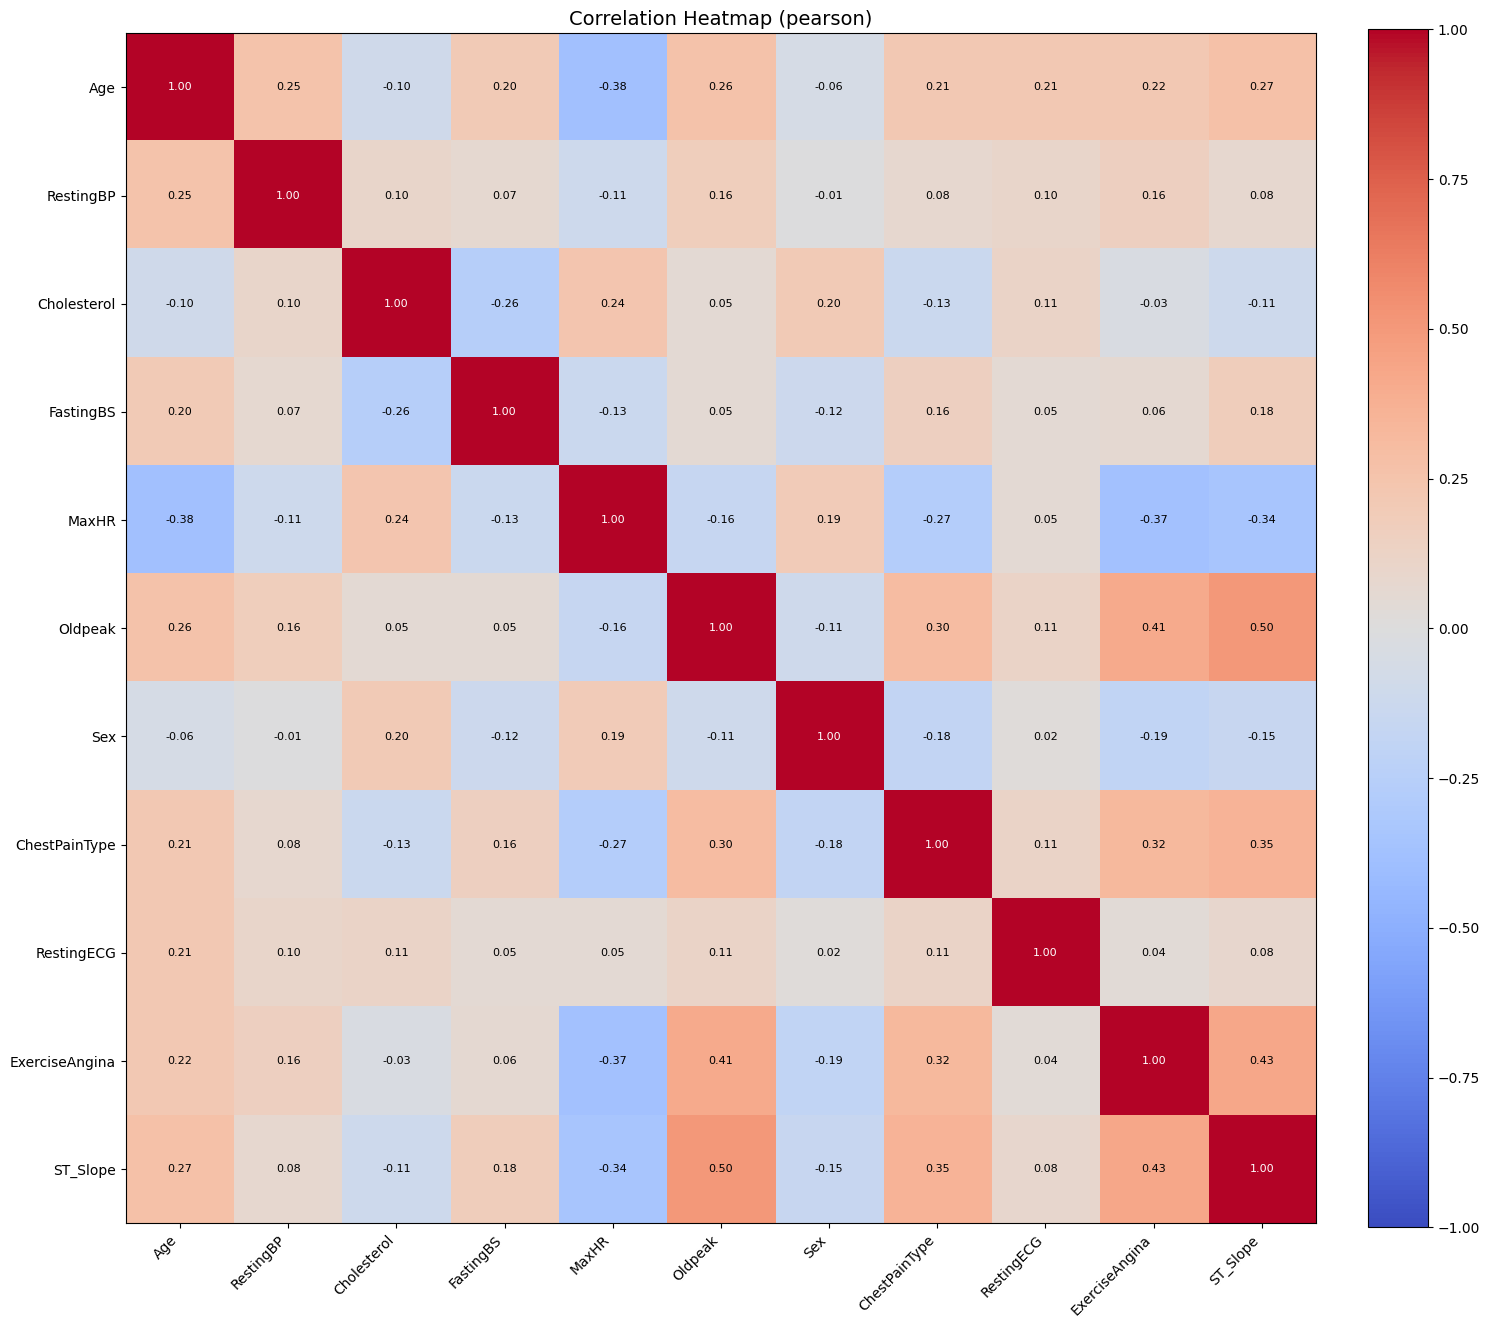

In [5]:
inspector = FeatureInspector(
    df,
    categorical_cols=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"],
    numeric_cols=["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"],
    target_col="HeartDisease",
)

inspector.summarize()
inspector.plot_categorical_counts()
inspector.plot_corr_heatmap(include_categorical=True)


#### Men category > Women category => Use this for fairness evaluation

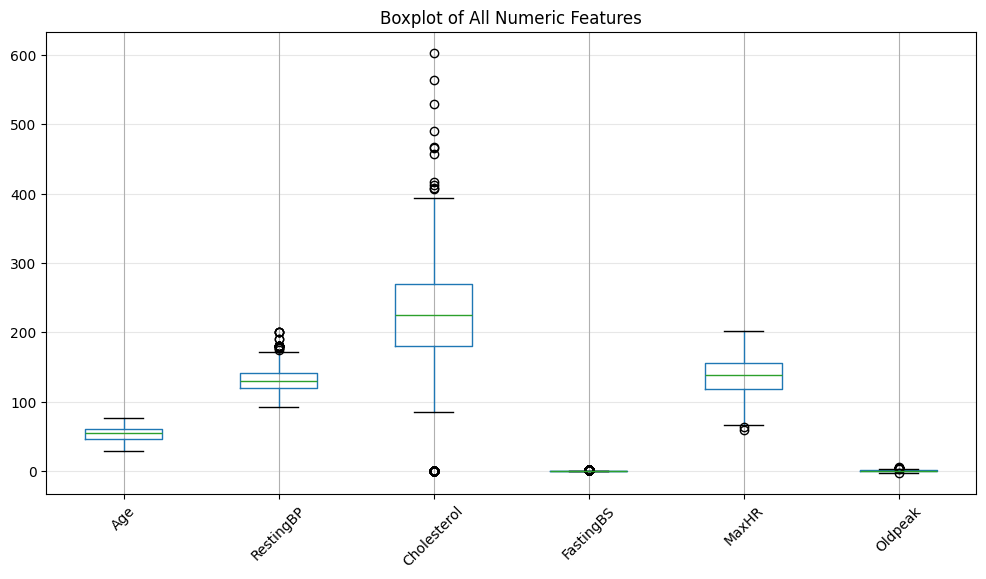

In [6]:


# 0) 원본 데이터에서 먼저 split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["HeartDisease"]
)

categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
numeric_cols     = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

pre = DataPreprocessor(
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    target_col="HeartDisease",
)

# 1) (선택) train 데이터로만 boxplot 확인
pre.plot_all_boxplots(train_df)

# 2) (선택) outlier clipping도 train에만 적용하고 싶으면 여기서:
# train_df = pre.clip_outliers_iqr(train_df, inplace=False)
# test_df  = pre.clip_outliers_iqr(test_df, inplace=False)  # train에서 구한 bound를 쓰려면 설계를 좀 더 바꿔야 함

# 3) 전처리: **train으로만 fit**
pre.fit(train_df)

# 4) 같은 preprocessor로 train/test 모두 transform
train_processed = pre.transform(train_df)
test_processed  = pre.transform(test_df)


In [7]:
X_train = train_processed.drop("HeartDisease", axis=1)
y_train = train_processed["HeartDisease"]
X_test = test_processed.drop("HeartDisease", axis=1)
y_test = test_processed["HeartDisease"]
sex_test = test_df["Sex"]

In [8]:
input_dim = X_train.shape[1]
models = get_models(input_dim=input_dim)

overall_results = evaluate_models(models, X_train, y_train, X_test, y_test)
group_train = train_df["Sex"]     # 또는 원본에서 align
group_test  = test_df["Sex"]
mlp_fair_tpr = TorchMLPClassifier(
    input_dim=X_train.shape[1],
    hidden_dims=(64, 32),
    lr=1e-3,
    epochs=100,
    batch_size=64,
    fairness_lambda=1.0,
    fairness_type="tpr",      # TPR fairness penalty
    random_state=42,
    name="mlp_bce_tpr_1.0",
)

mlp_fair_tpr.fit(X_train, y_train, group=group_train)
# mlp_fair_df = evaluate_fair_mlp(
#     X_train=X_train,
#     y_train=y_train,
#     X_test=X_test,
#     y_test=y_test,
#     group_train=group_train,
#     fairness_lambda=1.0,   # 원하는 값
#     hidden_dims=(64, 32),
#     lr=1e-3,
#     epochs=100,
#     batch_size=64,
#     random_state=42,
# )

# # 기존 결과와 합치기
# overall_with_fair = pd.concat([overall_results, mlp_fair_df], ignore_index=True)
# print(overall_with_fair[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]])

In [9]:
proba = mlp_fair_tpr.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)


cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
overall_fair_tpr = pd.DataFrame([{
    "model": "mlp_bce_tpr_1.0",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
    "confusion_matrix": cm,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
}])


In [10]:
overall_all = pd.concat([overall_results, overall_fair_tpr], ignore_index=True)
print(overall_all)


                 model  accuracy  precision    recall        f1   roc_auc  \
0  logistic_regression  0.875000   0.855856  0.931373  0.892019  0.896820   
1        random_forest  0.891304   0.886792  0.921569  0.903846  0.929460   
2              xgboost  0.880435   0.900000  0.882353  0.891089  0.930177   
3    linear_regression  0.875000   0.876190  0.901961  0.888889  0.895026   
4     ridge_regression  0.875000   0.876190  0.901961  0.888889  0.895265   
5              mlp_bce  0.864130   0.881188  0.872549  0.876847  0.923242   
6      mlp_bce_tpr_1.0  0.869565   0.890000  0.872549  0.881188  0.917384   

       confusion_matrix  tn  fp  fn  tp  
0   [[66, 16], [7, 95]]  66  16   7  95  
1   [[70, 12], [8, 94]]  70  12   8  94  
2  [[72, 10], [12, 90]]  72  10  12  90  
3  [[69, 13], [10, 92]]  69  13  10  92  
4  [[69, 13], [10, 92]]  69  13  10  92  
5  [[70, 12], [13, 89]]  70  12  13  89  
6  [[71, 11], [13, 89]]  71  11  13  89  


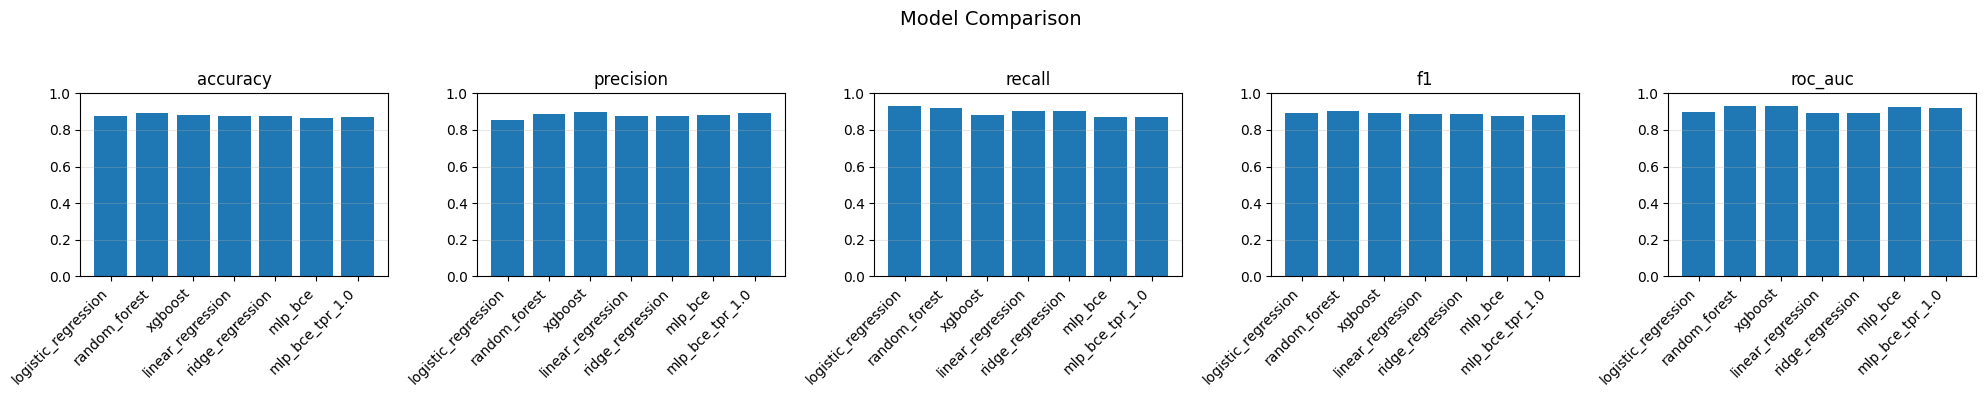

In [11]:
from model import plot_model_metrics
plot_model_metrics(overall_all)


#### Recall이나 Precision을 보면, Female에 대한 성능이 현저히 떨어지는 경우가 가끔 나타난다. => 이걸 Fairness_Loss를 반영하여 완화해보도록 하자.

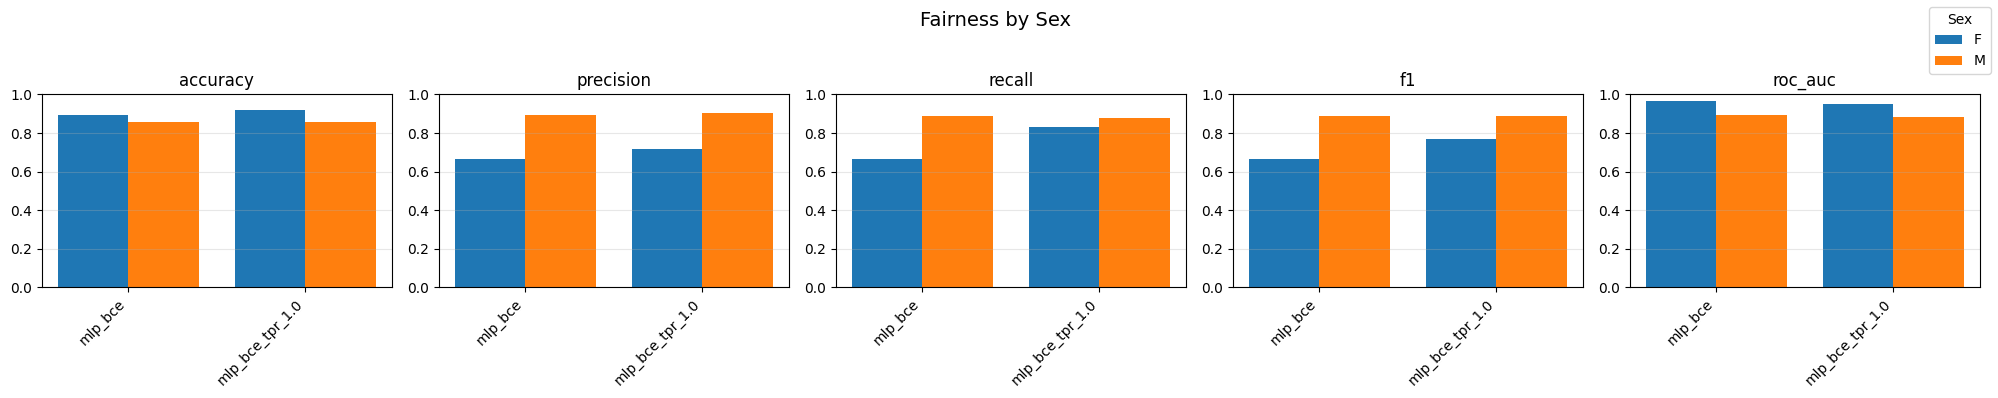

In [12]:
two_models = {
    "mlp_bce": models["mlp_bce"],          # 기존 BCE-only MLP (evaluate_models 후)
    "mlp_bce_tpr_1.0": mlp_fair_tpr,       # soft TPR fairness MLP
}

# 4) 성별 그룹 정보 (test)
sex_test = test_df["Sex"]  # 'M' / 'F'

# 5) 그룹별 성능 계산
group_results_2 = evaluate_models_by_group(
    models=two_models,
    X_test=X_test,
    y_test=y_test.values,
    group_values=sex_test,
    threshold=0.5,
    group_name="Sex",
)
plot_fairness_all_metrics(
    group_results_df=group_results_2,
    metrics=("accuracy", "precision", "recall", "f1", "roc_auc"),
    group_name="Sex",
)


In [13]:
# 1) 공정성 MLP 학습 (soft TPR 페널티 쓰는 버전)
group_train = train_df["Sex"]  # 'M'/'F'

# 2) 기존 models(dict) + 공정성 MLP 합치기
models_with_fair = dict(models)   # 원본 복사
models_with_fair["mlp_bce_tpr_1.0"] = mlp_fair_tpr

# 3) 성별별 성능 계산
sex_test = test_df["Sex"]

group_results = evaluate_models_by_group(
    models=models_with_fair,
    X_test=X_test,
    y_test=y_test.values,
    group_values=sex_test,
    threshold=0.5,
    group_name="Sex",
)

print(
    group_results[
        ["model", "Sex", "accuracy", "precision", "recall", "f1", "roc_auc", "tp", "fp", "fn", "tn"]
    ]
)


                  model Sex  accuracy  precision    recall        f1  \
0   logistic_regression   F  0.894737   0.625000  0.833333  0.714286   
1   logistic_regression   M  0.869863   0.873786  0.937500  0.904523   
2         random_forest   F  0.947368   0.833333  0.833333  0.833333   
3         random_forest   M  0.876712   0.890000  0.927083  0.908163   
4               xgboost   F  0.921053   0.800000  0.666667  0.727273   
5               xgboost   M  0.869863   0.905263  0.895833  0.900524   
6     linear_regression   F  0.921053   0.714286  0.833333  0.769231   
7     linear_regression   M  0.863014   0.887755  0.906250  0.896907   
8      ridge_regression   F  0.921053   0.714286  0.833333  0.769231   
9      ridge_regression   M  0.863014   0.887755  0.906250  0.896907   
10              mlp_bce   F  0.894737   0.666667  0.666667  0.666667   
11              mlp_bce   M  0.856164   0.894737  0.885417  0.890052   
12      mlp_bce_tpr_1.0   F  0.921053   0.714286  0.833333  0.76

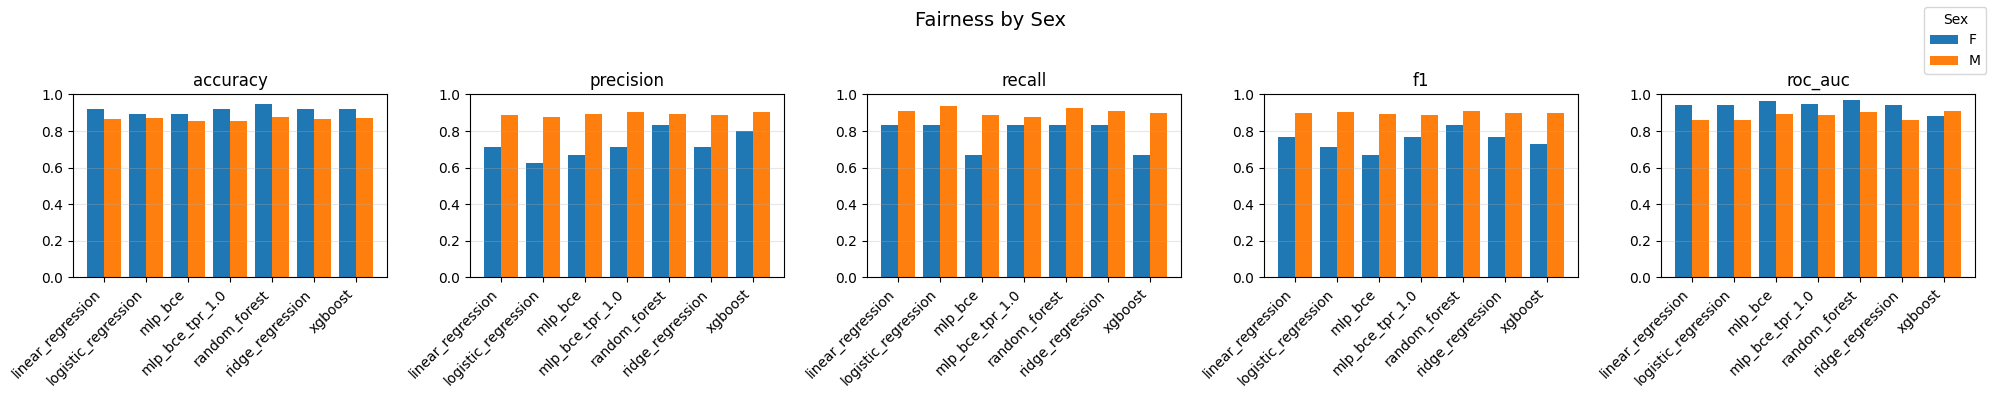

In [14]:
plot_fairness_all_metrics(
    group_results_df=group_results,
    metrics=("accuracy", "precision", "recall", "f1", "roc_auc"),
    group_name="Sex",
)


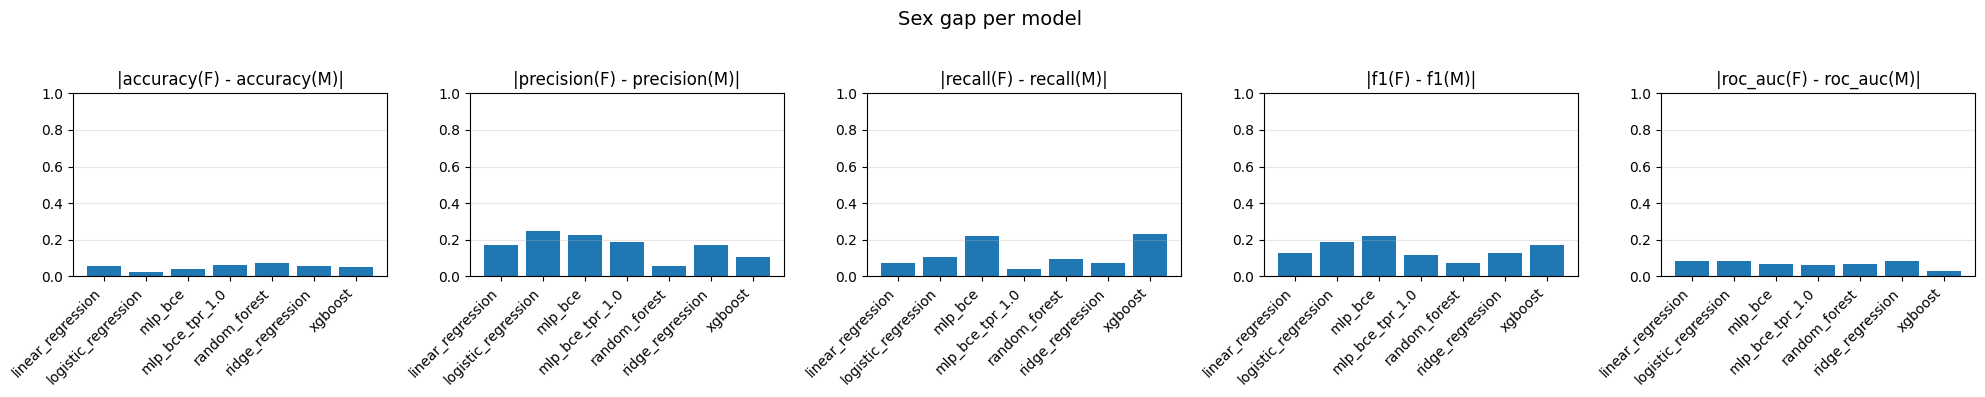

In [15]:
plot_fairness_gap(
    group_results_df=group_results,
    metrics=("accuracy", "precision", "recall", "f1", "roc_auc"),
    group_name="Sex",
)


### 어떤 feature이 제일 중요한지 분석해보자

In [16]:
shap_explainer = FairMLPShapExplainer(
    model=mlp_fair_tpr,
    X_train=X_train,                   # DataFrame or numpy
    feature_names=X_train.columns,     # optional
    background_size=50
)


In [17]:
shap_values = shap_explainer.compute_shap(X_test, nsamples=200)


  0%|          | 0/184 [00:00<?, ?it/s]

c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Coursework\heart_disease\explain.py:79: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(self.shap_values, X_np, feature_names=self.feature_names)


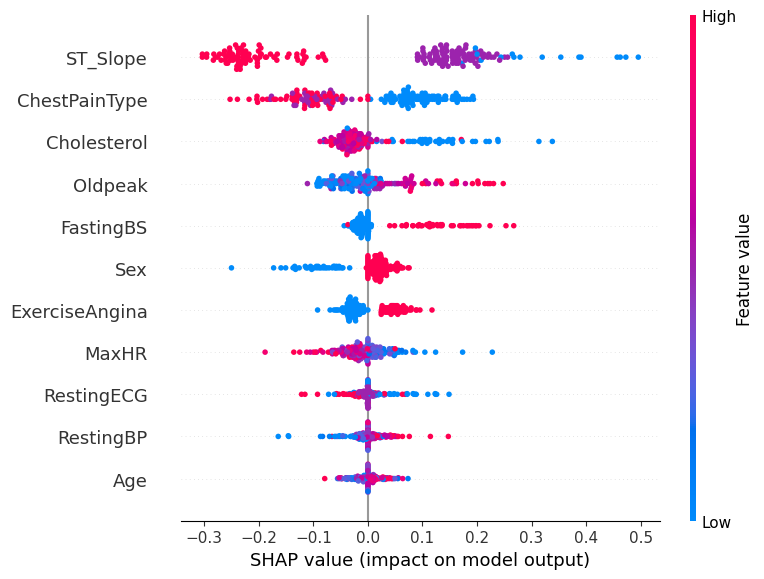

In [18]:
shap_explainer.plot_summary(X_test)


c:\Users\user\Desktop\UCL_Courses\AI in biomedicine and Healthcare\Coursework\heart_disease\explain.py:91: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(self.shap_values, X_np, feature_names=self.feature_names, plot_type="bar")


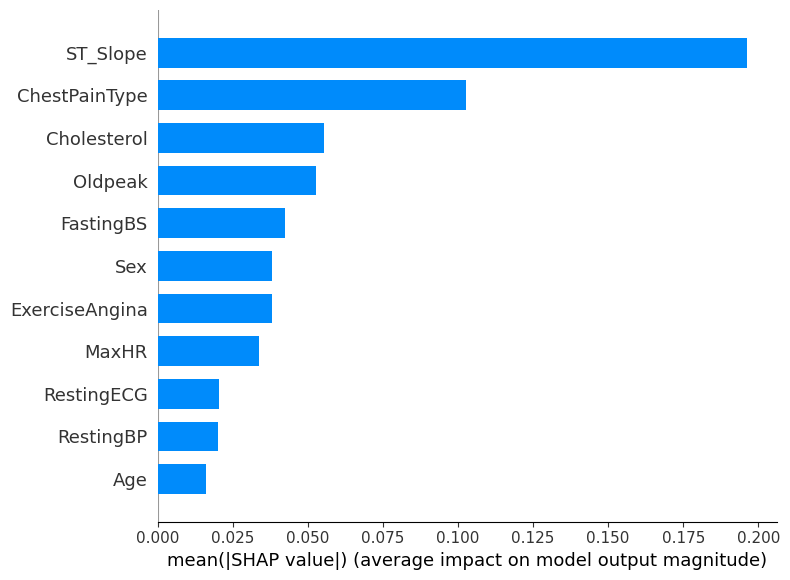

In [19]:
shap_explainer.plot_bar(X_test)


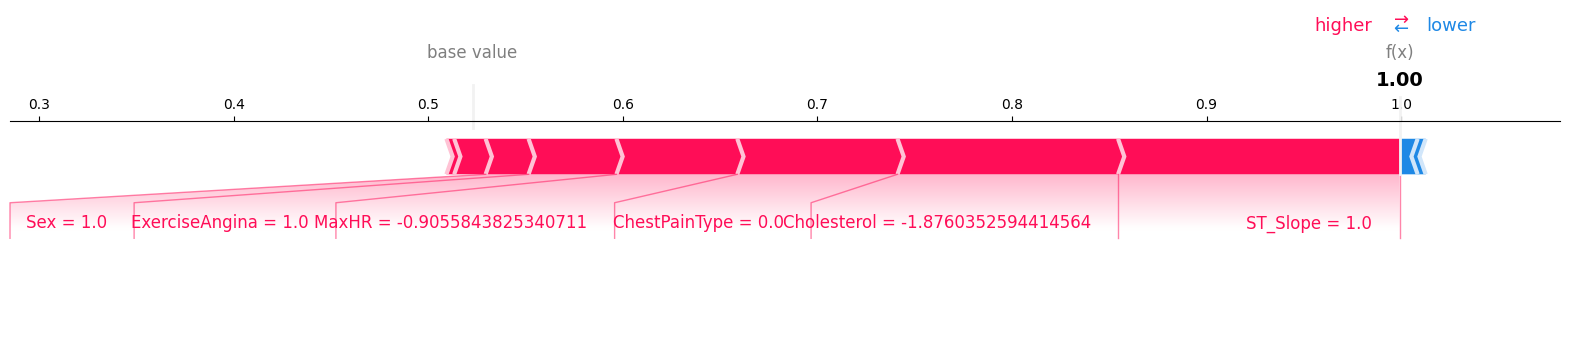

In [20]:
shap_explainer.plot_individual(X_test.values[0], index=0)
